# 10 — Deep-Learning Data Preparation

Generates Mel, MFCC, and chroma channels from the saved Notebook 04 4 kHz cycle WAVs, without repeating cycle extraction/resampling. It consumes the patient split created in Notebook 06. Features are cached in a compressed archive; augmentation is intentionally deferred to training loaders and will never touch validation/test cycles.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder

print("Imports completed successfully.")

Imports completed successfully.


In [2]:
PROJECT_ROOT = Path(
    "/Users/vs/Sem 5/Respiratory-Disease-Classification"
)

PROCESSED_CYCLES_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "processed_cycles.csv"
)

RECORDINGS_PATH = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "recordings.csv"
)

DL_OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "deep_learning"
)

DL_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:", PROJECT_ROOT)
print("Processed cycles:", PROCESSED_CYCLES_PATH)
print("Recordings:", RECORDINGS_PATH)
print("DL output directory:", DL_OUTPUT_DIR)

print("\nFiles available:")
print("processed_cycles.csv:", PROCESSED_CYCLES_PATH.exists())
print("recordings.csv:", RECORDINGS_PATH.exists())

Project root: /Users/vs/Sem 5/Respiratory-Disease-Classification
Processed cycles: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/processed_cycles.csv
Recordings: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/interim/recordings.csv
DL output directory: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning

Files available:
processed_cycles.csv: True
recordings.csv: True


In [3]:
processed_cycles_df = pd.read_csv(
    PROCESSED_CYCLES_PATH
)

recordings_df = pd.read_csv(
    RECORDINGS_PATH
)

print("Processed cycles shape:", processed_cycles_df.shape)
print("Recordings shape:", recordings_df.shape)

print("\nProcessed cycles columns:")
print(processed_cycles_df.columns.tolist())

print("\nRecordings columns:")
print(recordings_df.columns.tolist())

Processed cycles shape: (6898, 23)
Recordings shape: (920, 7)

Processed cycles columns:
['patient_id', 'diagnosis', 'recording_id', 'chest_location', 'acquisition_mode', 'equipment', 'cycle_number', 'sound_label', 'crackles', 'wheezes', 'start_time', 'end_time', 'original_sample_rate', 'target_sample_rate', 'original_samples', 'processed_samples', 'original_duration', 'processed_duration', 'original_peak', 'original_rms', 'normalized_peak', 'processed_path', 'processing_status']

Recordings columns:
['patient_id', 'recording_id', 'chest_location', 'acquisition_mode', 'equipment', 'wav_path', 'official_split']


In [4]:
features_with_split = processed_cycles_df.merge(
    recordings_df[
        [
            "patient_id",
            "recording_id",
            "chest_location",
            "official_split"
        ]
    ],
    on=[
        "patient_id",
        "recording_id",
        "chest_location"
    ],
    how="left",
    validate="many_to_one"
)

print("Merged dataset shape:", features_with_split.shape)

print("\nMissing official split values:")
print(
    features_with_split["official_split"].isna().sum()
)

Merged dataset shape: (6898, 24)

Missing official split values:
0


In [5]:
print("Official split distribution:")
print(
    features_with_split["official_split"]
    .value_counts()
)

print("\nSplit percentages:")
print(
    features_with_split["official_split"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Official split distribution:
official_split
train    4142
test     2756
Name: count, dtype: int64

Split percentages:
official_split
train    60.05
test     39.95
Name: proportion, dtype: float64


In [6]:
train_dl_df = features_with_split[
    features_with_split["official_split"] == "train"
].copy()

test_dl_df = features_with_split[
    features_with_split["official_split"] == "test"
].copy()

print("Training cycles:", len(train_dl_df))
print("Testing cycles :", len(test_dl_df))

print("\nTraining patients:", train_dl_df["patient_id"].nunique())
print("Testing patients :", test_dl_df["patient_id"].nunique())

print("\nTraining recordings:", train_dl_df["recording_id"].nunique())
print("Testing recordings :", test_dl_df["recording_id"].nunique())

Training cycles: 4142
Testing cycles : 2756

Training patients: 79
Testing patients : 49

Training recordings: 29
Testing recordings : 27


In [7]:
path_candidates = [
    col
    for col in features_with_split.columns
    if (
        "wav" in col.lower()
        or "audio" in col.lower()
        or "path" in col.lower()
    )
]

print("Possible audio/path columns:")
print(path_candidates)

if not path_candidates:
    raise ValueError(
        "No audio/path column found in processed_cycles.csv."
    )

wav_candidates = [
    col for col in path_candidates
    if "wav" in col.lower()
]

AUDIO_PATH_COLUMN = (
    wav_candidates[0]
    if wav_candidates
    else path_candidates[0]
)

print("\nSelected audio path column:")
print(AUDIO_PATH_COLUMN)

Possible audio/path columns:
['processed_path']

Selected audio path column:
processed_path


In [8]:
def resolve_audio_path(path_value):
    path = Path(str(path_value))

    # Absolute path
    if path.is_absolute():
        return path

    # Relative to project root
    candidate = PROJECT_ROOT / path

    if candidate.exists():
        return candidate

    # Relative to processed directory
    candidate = (
        PROJECT_ROOT
        / "data"
        / "processed"
        / path
    )

    if candidate.exists():
        return candidate

    return PROJECT_ROOT / path


features_with_split["audio_path"] = (
    features_with_split[AUDIO_PATH_COLUMN]
    .apply(resolve_audio_path)
)

features_with_split["audio_exists"] = (
    features_with_split["audio_path"]
    .apply(lambda p: p.exists())
)

print("Total cycle records:", len(features_with_split))
print(
    "Existing audio files:",
    features_with_split["audio_exists"].sum()
)
print(
    "Missing audio files:",
    (~features_with_split["audio_exists"]).sum()
)

Total cycle records: 6898
Existing audio files: 6898
Missing audio files: 0


In [9]:
print("Example processed audio paths:\n")

display(
    features_with_split[
        [
            "patient_id",
            "recording_id",
            "chest_location",
            "audio_path",
            "audio_exists"
        ]
    ].head(10)
)

Example processed audio paths:



,patient_id,recording_id,chest_location,audio_path,audio_exists
0,101,1b1,Al,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,True
1,101,1b1,Al,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,True
2,101,1b1,Al,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,True
3,101,1b1,Al,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,True
4,101,1b1,Al,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,True
5,101,1b1,Al,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,True
6,101,1b1,Al,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,True
7,101,1b1,Al,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,True
8,101,1b1,Al,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,True
9,101,1b1,Al,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,True


In [10]:
missing_audio_df = features_with_split[
    ~features_with_split["audio_exists"]
]

if len(missing_audio_df) > 0:
    print("Missing audio files found:")
    display(
        missing_audio_df[
            [
                "patient_id",
                "recording_id",
                "chest_location",
                "audio_path"
            ]
        ].head(20)
    )

    raise FileNotFoundError(
        f"{len(missing_audio_df)} processed audio files are missing."
    )

print("=" * 70)
print("AUDIO FILE VALIDATION PASSED")
print("=" * 70)
print(
    f"All {len(features_with_split)} respiratory-cycle "
    "audio files exist."
)

AUDIO FILE VALIDATION PASSED
All 6898 respiratory-cycle audio files exist.


In [11]:
import soundfile as sf

print("soundfile imported successfully.")

soundfile imported successfully.


In [12]:
example_path = features_with_split.iloc[0]["audio_path"]

signal, sample_rate = sf.read(example_path)

print("Example file:")
print(example_path)

print("\nAudio properties:")
print("Sample rate :", sample_rate)
print("Samples     :", len(signal))
print("Duration    :", len(signal) / sample_rate, "seconds")
print("Shape       :", signal.shape)
print("Minimum     :", np.min(signal))
print("Maximum     :", np.max(signal))
print("Finite      :", np.isfinite(signal).all())

Example file:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/audio/cycles/101/1b1_Al_001.wav

Audio properties:
Sample rate : 4000
Samples     : 2172
Duration    : 0.543 seconds
Shape       : (2172,)
Minimum     : -0.486724853515625
Maximum     : 0.999969482421875
Finite      : True


In [13]:
sample_rates = []
channel_counts = []
sample_counts = []
durations = []
invalid_audio = []

for idx, row in features_with_split.iterrows():

    path = row["audio_path"]

    try:
        info = sf.info(path)

        sample_rates.append(info.samplerate)
        channel_counts.append(info.channels)
        sample_counts.append(info.frames)
        durations.append(info.duration)

    except Exception as e:
        invalid_audio.append({
            "index": idx,
            "path": str(path),
            "error": str(e)
        })

print("=" * 70)
print("AUDIO PROPERTY VALIDATION")
print("=" * 70)

print("Files checked :", len(features_with_split))
print("Invalid files :", len(invalid_audio))

print("\nSample rates:")
print(pd.Series(sample_rates).value_counts().sort_index())

print("\nChannel counts:")
print(pd.Series(channel_counts).value_counts().sort_index())

print("\nDuration statistics:")
print(
    pd.Series(durations).describe()
)

AUDIO PROPERTY VALIDATION
Files checked : 6898
Invalid files : 0

Sample rates:
4000    6898
Name: count, dtype: int64

Channel counts:
1    6898
Name: count, dtype: int64

Duration statistics:
count    6898.000000
mean        2.700606
std         1.172531
min         0.200000
25%         1.932250
50%         2.537000
75%         3.369250
max        16.163000
dtype: float64


In [17]:
# ============================================================
# STEP 5 — AUDIO DURATION ANALYSIS
# ============================================================

import soundfile as sf

durations = []

for path in features_with_split["audio_path"]:
    info = sf.info(path)
    durations.append(info.duration)

duration_series = pd.Series(
    durations,
    name="audio_duration"
)

print("=" * 70)
print("AUDIO DURATION ANALYSIS")
print("=" * 70)

print("\nDuration statistics:")
print(duration_series.describe())

print("\nDuration percentiles:")
print(
    duration_series.quantile(
        [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nPercentage of cycles covered by candidate durations:")

for duration in [1.5, 2.0, 2.5, 3.0, 4.0, 5.0]:

    percentage = (
        duration_series <= duration
    ).mean() * 100

    print(
        f"{duration:.1f} seconds: "
        f"{percentage:.2f}%"
    )

AUDIO DURATION ANALYSIS

Duration statistics:
count    6898.000000
mean        2.700606
std         1.172531
min         0.200000
25%         1.932250
50%         2.537000
75%         3.369250
max        16.163000
Name: audio_duration, dtype: float64

Duration percentiles:
0.01    0.61525
0.05    1.04725
0.10    1.33400
0.25    1.93225
0.50    2.53700
0.75    3.36925
0.90    4.10725
0.95    4.59100
0.99    6.41100
Name: audio_duration, dtype: float64

Percentage of cycles covered by candidate durations:
1.5 seconds: 13.53%
2.0 seconds: 27.41%
2.5 seconds: 48.42%
3.0 seconds: 64.84%
4.0 seconds: 88.53%
5.0 seconds: 96.62%


In [18]:
# ============================================================
# STEP 5 — FIXED-LENGTH AUDIO CONFIGURATION
# ============================================================

TARGET_SR = 4000
TARGET_DURATION = 5.0
TARGET_SAMPLES = int(TARGET_SR * TARGET_DURATION)

print("=" * 70)
print("FIXED-LENGTH AUDIO CONFIGURATION")
print("=" * 70)

print("Target sample rate :", TARGET_SR, "Hz")
print("Target duration    :", TARGET_DURATION, "seconds")
print("Target samples     :", TARGET_SAMPLES)

FIXED-LENGTH AUDIO CONFIGURATION
Target sample rate : 4000 Hz
Target duration    : 5.0 seconds
Target samples     : 20000


In [19]:
def fix_audio_length(
    signal,
    target_samples=TARGET_SAMPLES
):
    """
    Convert a respiratory-cycle waveform to a fixed number
    of samples using zero-padding or truncation.
    """

    signal = np.asarray(signal, dtype=np.float32)

    current_samples = len(signal)

    if current_samples == target_samples:
        return signal

    if current_samples < target_samples:
        padded_signal = np.zeros(
            target_samples,
            dtype=np.float32
        )

        padded_signal[:current_samples] = signal

        return padded_signal

    return signal[:target_samples]

In [20]:
import soundfile as sf

# Short cycle
short_path = (
    features_with_split
    .sort_values("audio_duration" if "audio_duration" in features_with_split.columns else AUDIO_PATH_COLUMN)
    .iloc[0]["audio_path"]
)

# Long cycle
long_path = (
    features_with_split
    .iloc[-1]["audio_path"]
)

short_signal, short_sr = sf.read(short_path)
long_signal, long_sr = sf.read(long_path)

short_fixed = fix_audio_length(short_signal)
long_fixed = fix_audio_length(long_signal)

print("Short example:")
print("Original samples :", len(short_signal))
print("Fixed samples    :", len(short_fixed))
print("Original duration:", len(short_signal) / short_sr)
print("Fixed duration   :", len(short_fixed) / TARGET_SR)

print("\nLong example:")
print("Original samples :", len(long_signal))
print("Fixed samples    :", len(long_fixed))
print("Original duration:", len(long_signal) / long_sr)
print("Fixed duration   :", len(long_fixed) / TARGET_SR)

assert len(short_fixed) == TARGET_SAMPLES
assert len(long_fixed) == TARGET_SAMPLES

print("\nFixed-length audio validation passed.")

Short example:
Original samples : 2172
Fixed samples    : 20000
Original duration: 0.543
Fixed duration   : 5.0

Long example:
Original samples : 2172
Fixed samples    : 20000
Original duration: 0.543
Fixed duration   : 5.0

Fixed-length audio validation passed.


In [21]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

print("librosa version:", librosa.__version__)

librosa version: 1.0.0


In [22]:
# ============================================================
# STEP 6 — FIRST LOG-MEL SPECTROGRAM
# ============================================================

# Use a representative processed cycle
example_row = features_with_split.iloc[0]

example_path = example_row["audio_path"]

signal, sr = sf.read(example_path)

# Ensure mono
if signal.ndim > 1:
    signal = np.mean(signal, axis=1)

# Fixed 5-second representation
fixed_signal = fix_audio_length(signal)

# Mel-spectrogram parameters
N_FFT = 512
HOP_LENGTH = 128
N_MELS = 64

mel_power = librosa.feature.melspectrogram(
    y=fixed_signal.astype(np.float32),
    sr=TARGET_SR,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    fmin=0,
    fmax=TARGET_SR // 2,
    power=2.0
)

mel_db = librosa.power_to_db(
    mel_power,
    ref=np.max
)

print("Example file:")
print(example_path)

print("\nOriginal signal:")
print("Samples:", len(signal))
print("Duration:", len(signal) / sr)

print("\nFixed signal:")
print("Samples:", len(fixed_signal))
print("Duration:", len(fixed_signal) / TARGET_SR)

print("\nMel spectrogram:")
print("Shape:", mel_db.shape)
print("Minimum dB:", mel_db.min())
print("Maximum dB:", mel_db.max())

Example file:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/audio/cycles/101/1b1_Al_001.wav

Original signal:
Samples: 2172
Duration: 0.543

Fixed signal:
Samples: 20000
Duration: 5.0

Mel spectrogram:
Shape: (64, 157)
Minimum dB: -80.0
Maximum dB: 0.0


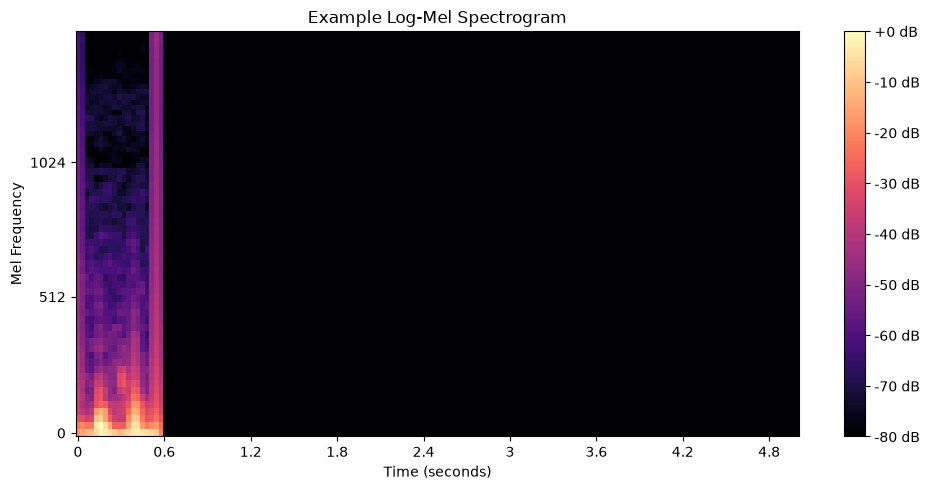

In [23]:
plt.figure(figsize=(10, 5))

librosa.display.specshow(
    mel_db,
    sr=TARGET_SR,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel",
    fmin=0,
    fmax=TARGET_SR // 2
)

plt.colorbar(format="%+2.0f dB")
plt.title("Example Log-Mel Spectrogram")
plt.xlabel("Time (seconds)")
plt.ylabel("Mel Frequency")

plt.tight_layout()
plt.show()

In [24]:
assert fixed_signal.shape == (TARGET_SAMPLES,)
assert mel_db.shape[0] == N_MELS
assert np.isfinite(mel_db).all()

print("=" * 70)
print("STEP 6 VALIDATION")
print("=" * 70)

print("Fixed audio shape :", fixed_signal.shape)
print("Mel shape         :", mel_db.shape)
print("All values finite :", np.isfinite(mel_db).all())

print("\nLog-Mel spectrogram validation passed.")

STEP 6 VALIDATION
Fixed audio shape : (20000,)
Mel shape         : (64, 157)
All values finite : True

Log-Mel spectrogram validation passed.


In [25]:
# ============================================================
# STEP 7 — SPECTROGRAM CONFIGURATION
# ============================================================

TARGET_SR = 4000
TARGET_DURATION = 5.0
TARGET_SAMPLES = int(TARGET_SR * TARGET_DURATION)

N_FFT = 512
HOP_LENGTH = 128
N_MELS = 64
FMIN = 0
FMAX = TARGET_SR // 2

print("Target sample rate :", TARGET_SR)
print("Target duration    :", TARGET_DURATION, "seconds")
print("Target samples     :", TARGET_SAMPLES)
print("N_FFT              :", N_FFT)
print("Hop length         :", HOP_LENGTH)
print("Mel bands           :", N_MELS)
print("Frequency range     :", FMIN, "-", FMAX, "Hz")

Target sample rate : 4000
Target duration    : 5.0 seconds
Target samples     : 20000
N_FFT              : 512
Hop length         : 128
Mel bands           : 64
Frequency range     : 0 - 2000 Hz


In [26]:
def audio_to_log_mel(
    audio_path,
    target_sr=TARGET_SR,
    target_samples=TARGET_SAMPLES,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    fmin=FMIN,
    fmax=FMAX
):
    """
    Load a processed respiratory-cycle WAV file,
    convert it to a fixed-length waveform, and generate
    a log-Mel spectrogram.
    """

    signal, sr = sf.read(audio_path)

    # Ensure mono
    if signal.ndim > 1:
        signal = np.mean(signal, axis=1)

    # Verify expected sample rate
    if sr != target_sr:
        raise ValueError(
            f"Unexpected sample rate {sr} for {audio_path}. "
            f"Expected {target_sr}."
        )

    # Convert to float32
    signal = signal.astype(np.float32)

    # Fixed-length representation
    signal = fix_audio_length(
        signal,
        target_samples=target_samples
    )

    # Mel spectrogram
    mel_power = librosa.feature.melspectrogram(
        y=signal,
        sr=target_sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        fmin=fmin,
        fmax=fmax,
        power=2.0
    )

    # Convert power spectrogram to decibels
    mel_db = librosa.power_to_db(
        mel_power,
        ref=np.max
    )

    return mel_db.astype(np.float32)

In [27]:
# ============================================================
# TEST THE FUNCTION ON DIFFERENT CYCLE DURATIONS
# ============================================================

test_indices = [
    0,
    len(features_with_split) // 4,
    len(features_with_split) // 2,
    len(features_with_split) - 1
]

for idx in test_indices:

    path = features_with_split.iloc[idx]["audio_path"]

    original_info = sf.info(path)

    mel = audio_to_log_mel(path)

    print(
        f"Index {idx:4d} | "
        f"Original duration: {original_info.duration:7.3f}s | "
        f"Mel shape: {mel.shape} | "
        f"Finite: {np.isfinite(mel).all()}"
    )

    assert mel.shape == (N_MELS, 157)
    assert np.isfinite(mel).all()

print("\nAll test spectrograms generated successfully.")

Index    0 | Original duration:   0.543s | Mel shape: (64, 157) | Finite: True
Index 1724 | Original duration:   4.171s | Mel shape: (64, 157) | Finite: True
Index 3449 | Original duration:   1.035s | Mel shape: (64, 157) | Finite: True
Index 6897 | Original duration:   0.543s | Mel shape: (64, 157) | Finite: True

All test spectrograms generated successfully.


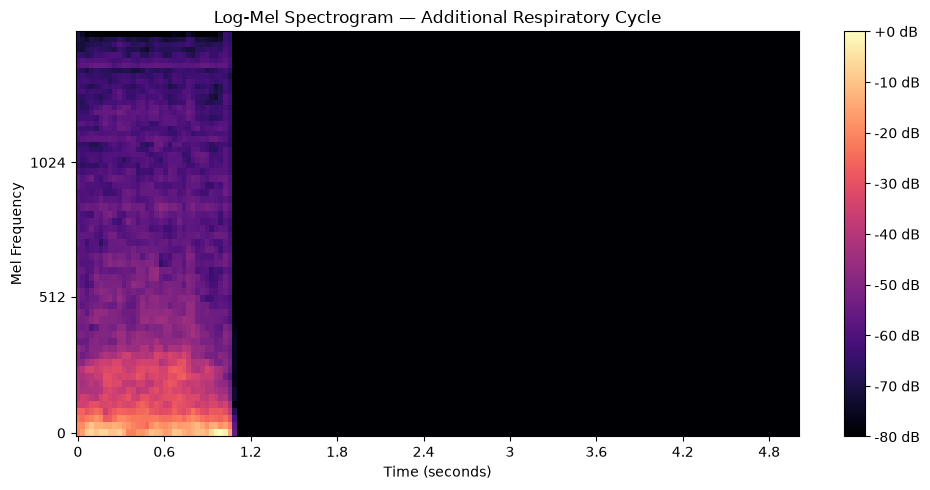

In [28]:
idx = len(features_with_split) // 2

example_path = features_with_split.iloc[idx]["audio_path"]
example_mel = audio_to_log_mel(example_path)

plt.figure(figsize=(10, 5))

librosa.display.specshow(
    example_mel,
    sr=TARGET_SR,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel",
    fmin=FMIN,
    fmax=FMAX
)

plt.colorbar(format="%+2.0f dB")
plt.title("Log-Mel Spectrogram — Additional Respiratory Cycle")
plt.xlabel("Time (seconds)")
plt.ylabel("Mel Frequency")

plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# STEP 8 — DISEASE LABEL ENCODING
# ============================================================

label_encoder_dl = LabelEncoder()

features_with_split["disease_label"] = (
    label_encoder_dl.fit_transform(
        features_with_split["diagnosis"]
    )
)

class_names_dl = label_encoder_dl.classes_

print("Disease classes:")
for label, disease in enumerate(class_names_dl):
    print(f"{label}: {disease}")

print("\nNumber of classes:", len(class_names_dl))

Disease classes:
0: Asthma
1: Bronchiectasis
2: Bronchiolitis
3: COPD
4: Healthy
5: LRTI
6: Pneumonia
7: URTI

Number of classes: 8


In [30]:
# ============================================================
# CREATE DEEP LEARNING MANIFEST
# ============================================================

manifest_columns = [
    "patient_id",
    "recording_id",
    "chest_location",
    "diagnosis",
    "disease_label",
    "official_split",
    "audio_path"
]

dl_manifest = features_with_split[
    manifest_columns
].copy()

# Store paths as strings for CSV compatibility
dl_manifest["audio_path"] = (
    dl_manifest["audio_path"].astype(str)
)

print("Manifest shape:", dl_manifest.shape)

display(dl_manifest.head())

Manifest shape: (6898, 7)


,patient_id,recording_id,chest_location,diagnosis,disease_label,official_split,audio_path
0,101,1b1,Al,URTI,7,test,/Users/vs/Sem 5/Respiratory-Disease-Classifica...
1,101,1b1,Al,URTI,7,test,/Users/vs/Sem 5/Respiratory-Disease-Classifica...
2,101,1b1,Al,URTI,7,test,/Users/vs/Sem 5/Respiratory-Disease-Classifica...
3,101,1b1,Al,URTI,7,test,/Users/vs/Sem 5/Respiratory-Disease-Classifica...
4,101,1b1,Al,URTI,7,test,/Users/vs/Sem 5/Respiratory-Disease-Classifica...


In [31]:
# ============================================================
# MANIFEST VALIDATION
# ============================================================

print("=" * 70)
print("DEEP LEARNING MANIFEST VALIDATION")
print("=" * 70)

print("Total cycles:", len(dl_manifest))

print("\nMissing values:")
print(
    dl_manifest.isna().sum()
)

print("\nSplit distribution:")
print(
    dl_manifest["official_split"].value_counts()
)

print("\nDisease distribution:")
print(
    dl_manifest["diagnosis"]
    .value_counts()
    .reindex(class_names_dl, fill_value=0)
)

print("\nDisease label distribution:")
print(
    dl_manifest["disease_label"]
    .value_counts()
    .sort_index()
)

DEEP LEARNING MANIFEST VALIDATION
Total cycles: 6898

Missing values:
patient_id        0
recording_id      0
chest_location    0
diagnosis         0
disease_label     0
official_split    0
audio_path        0
dtype: int64

Split distribution:
official_split
train    4142
test     2756
Name: count, dtype: int64

Disease distribution:
diagnosis
Asthma               6
Bronchiectasis     104
Bronchiolitis      160
COPD              5746
Healthy            322
LRTI                32
Pneumonia          285
URTI               243
Name: count, dtype: int64

Disease label distribution:
disease_label
0       6
1     104
2     160
3    5746
4     322
5      32
6     285
7     243
Name: count, dtype: int64


In [32]:
# ============================================================
# SAVE MANIFEST
# ============================================================

MANIFEST_PATH = (
    DL_OUTPUT_DIR
    / "deep_learning_manifest.csv"
)

CLASS_MAPPING_PATH = (
    DL_OUTPUT_DIR
    / "disease_class_mapping.csv"
)

dl_manifest.to_csv(
    MANIFEST_PATH,
    index=False
)

class_mapping_df = pd.DataFrame({
    "disease_label": np.arange(len(class_names_dl)),
    "diagnosis": class_names_dl
})

class_mapping_df.to_csv(
    CLASS_MAPPING_PATH,
    index=False
)

print("Manifest saved to:")
print(MANIFEST_PATH)

print("\nClass mapping saved to:")
print(CLASS_MAPPING_PATH)

Manifest saved to:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/deep_learning_manifest.csv

Class mapping saved to:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/disease_class_mapping.csv


In [33]:
# ============================================================
# STEP 8 VALIDATION
# ============================================================

assert len(dl_manifest) == 6898
assert len(class_names_dl) == 8
assert dl_manifest["diagnosis"].notna().all()
assert dl_manifest["disease_label"].notna().all()
assert dl_manifest["official_split"].notna().all()
assert dl_manifest["audio_path"].notna().all()

print("=" * 70)
print("STEP 8 VALIDATION PASSED")
print("=" * 70)

print("Manifest records :", len(dl_manifest))
print("Disease classes  :", len(class_names_dl))
print("Manifest saved   :", MANIFEST_PATH.exists())
print("Class mapping    :", CLASS_MAPPING_PATH.exists())

STEP 8 VALIDATION PASSED
Manifest records : 6898
Disease classes  : 8
Manifest saved   : True
Class mapping    : True


In [34]:
# ============================================================
# STEP 9 — CNN SPECTROGRAM STORAGE
# ============================================================

MEL_SHAPE = (N_MELS, 157)

TRAIN_MEL_PATH = (
    DL_OUTPUT_DIR / "X_train_logmel.npy"
)

TEST_MEL_PATH = (
    DL_OUTPUT_DIR / "X_test_logmel.npy"
)

TRAIN_LABEL_PATH = (
    DL_OUTPUT_DIR / "y_train.npy"
)

TEST_LABEL_PATH = (
    DL_OUTPUT_DIR / "y_test.npy"
)

TRAIN_MANIFEST_PATH = (
    DL_OUTPUT_DIR / "train_manifest.csv"
)

TEST_MANIFEST_PATH = (
    DL_OUTPUT_DIR / "test_manifest.csv"
)

train_manifest = dl_manifest[
    dl_manifest["official_split"] == "train"
].copy().reset_index(drop=True)

test_manifest = dl_manifest[
    dl_manifest["official_split"] == "test"
].copy().reset_index(drop=True)

print("Training samples :", len(train_manifest))
print("Testing samples  :", len(test_manifest))
print("Mel shape        :", MEL_SHAPE)
print("Data type        :", np.float32)

train_size_mb = (
    len(train_manifest)
    * MEL_SHAPE[0]
    * MEL_SHAPE[1]
    * np.dtype(np.float32).itemsize
    / (1024 ** 2)
)

test_size_mb = (
    len(test_manifest)
    * MEL_SHAPE[0]
    * MEL_SHAPE[1]
    * np.dtype(np.float32).itemsize
    / (1024 ** 2)
)

print(f"\nEstimated train storage: {train_size_mb:.2f} MB")
print(f"Estimated test storage : {test_size_mb:.2f} MB")
print(
    f"Estimated total storage: "
    f"{train_size_mb + test_size_mb:.2f} MB"
)

Training samples : 4142
Testing samples  : 2756
Mel shape        : (64, 157)
Data type        : <class 'numpy.float32'>

Estimated train storage: 158.76 MB
Estimated test storage : 105.64 MB
Estimated total storage: 264.40 MB


In [35]:
# ============================================================
# ALLOCATE MEMORY-MAPPED SPECTROGRAM ARRAYS
# ============================================================

X_train_mmap = np.lib.format.open_memmap(
    TRAIN_MEL_PATH,
    mode="w+",
    dtype=np.float32,
    shape=(
        len(train_manifest),
        N_MELS,
        157
    )
)

X_test_mmap = np.lib.format.open_memmap(
    TEST_MEL_PATH,
    mode="w+",
    dtype=np.float32,
    shape=(
        len(test_manifest),
        N_MELS,
        157
    )
)

print("Training array created:")
print(X_train_mmap.shape)

print("\nTesting array created:")
print(X_test_mmap.shape)

print("\nStorage files:")
print(TRAIN_MEL_PATH)
print(TEST_MEL_PATH)

Training array created:
(4142, 64, 157)

Testing array created:
(2756, 64, 157)

Storage files:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/X_train_logmel.npy
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/X_test_logmel.npy


In [36]:
# ============================================================
# SAVE LABELS AND MANIFESTS
# ============================================================

y_train_dl = train_manifest["disease_label"].to_numpy(
    dtype=np.int64
)

y_test_dl = test_manifest["disease_label"].to_numpy(
    dtype=np.int64
)

np.save(
    TRAIN_LABEL_PATH,
    y_train_dl
)

np.save(
    TEST_LABEL_PATH,
    y_test_dl
)

train_manifest.to_csv(
    TRAIN_MANIFEST_PATH,
    index=False
)

test_manifest.to_csv(
    TEST_MANIFEST_PATH,
    index=False
)

print("Saved:")
print(TRAIN_LABEL_PATH)
print(TEST_LABEL_PATH)
print(TRAIN_MANIFEST_PATH)
print(TEST_MANIFEST_PATH)

Saved:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/y_train.npy
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/y_test.npy
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/train_manifest.csv
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/test_manifest.csv


In [37]:
# ============================================================
# STEP 9 VALIDATION
# ============================================================

print("=" * 70)
print("STEP 9 VALIDATION")
print("=" * 70)

print("Train spectrogram shape:", X_train_mmap.shape)
print("Test spectrogram shape :", X_test_mmap.shape)

print("Train labels shape     :", y_train_dl.shape)
print("Test labels shape      :", y_test_dl.shape)

assert X_train_mmap.shape == (
    len(train_manifest),
    N_MELS,
    157
)

assert X_test_mmap.shape == (
    len(test_manifest),
    N_MELS,
    157
)

assert len(y_train_dl) == len(train_manifest)
assert len(y_test_dl) == len(test_manifest)

assert set(y_train_dl).issubset(
    set(range(len(class_names_dl)))
)

assert set(y_test_dl).issubset(
    set(range(len(class_names_dl)))
)

print("\nStorage allocation validated successfully.")

STEP 9 VALIDATION
Train spectrogram shape: (4142, 64, 157)
Test spectrogram shape : (2756, 64, 157)
Train labels shape     : (4142,)
Test labels shape      : (2756,)

Storage allocation validated successfully.


In [38]:
# ============================================================
# STEP 10 — GENERATE TRAINING LOG-MEL SPECTROGRAMS
# ============================================================

from tqdm.auto import tqdm

train_errors = []

for i, row in tqdm(
    train_manifest.iterrows(),
    total=len(train_manifest),
    desc="Processing training spectrograms"
):

    try:
        mel = audio_to_log_mel(
            row["audio_path"]
        )

        if mel.shape != (N_MELS, 157):
            raise ValueError(
                f"Unexpected Mel shape: {mel.shape}"
            )

        if not np.isfinite(mel).all():
            raise ValueError(
                "Non-finite values found in spectrogram."
            )

        X_train_mmap[i] = mel

    except Exception as e:

        train_errors.append({
            "index": i,
            "audio_path": row["audio_path"],
            "error": str(e)
        })

print("\nTraining processing complete.")
print("Successful:", len(train_manifest) - len(train_errors))
print("Errors    :", len(train_errors))

Processing training spectrograms:   0%|          | 0/4142 [00:00<?, ?it/s]


Training processing complete.
Successful: 4142
Errors    : 0


In [39]:
if train_errors:

    train_errors_df = pd.DataFrame(
        train_errors
    )

    display(train_errors_df.head(20))

    raise RuntimeError(
        f"{len(train_errors)} training spectrograms failed."
    )

else:

    train_errors_df = pd.DataFrame(
        columns=[
            "index",
            "audio_path",
            "error"
        ]
    )

    print(
        "All training spectrograms generated successfully."
    )

All training spectrograms generated successfully.


In [40]:
X_train_mmap.flush()

print("Training spectrogram data flushed to disk.")

print(
    "Training array shape:",
    X_train_mmap.shape
)

Training spectrogram data flushed to disk.
Training array shape: (4142, 64, 157)


In [41]:
# ============================================================
# GENERATE TESTING LOG-MEL SPECTROGRAMS
# ============================================================

test_errors = []

for i, row in tqdm(
    test_manifest.iterrows(),
    total=len(test_manifest),
    desc="Processing testing spectrograms"
):

    try:
        mel = audio_to_log_mel(
            row["audio_path"]
        )

        if mel.shape != (N_MELS, 157):
            raise ValueError(
                f"Unexpected Mel shape: {mel.shape}"
            )

        if not np.isfinite(mel).all():
            raise ValueError(
                "Non-finite values found in spectrogram."
            )

        X_test_mmap[i] = mel

    except Exception as e:

        test_errors.append({
            "index": i,
            "audio_path": row["audio_path"],
            "error": str(e)
        })

print("\nTesting processing complete.")
print("Successful:", len(test_manifest) - len(test_errors))
print("Errors    :", len(test_errors))

Processing testing spectrograms:   0%|          | 0/2756 [00:00<?, ?it/s]


Testing processing complete.
Successful: 2756
Errors    : 0


In [42]:
if test_errors:

    test_errors_df = pd.DataFrame(
        test_errors
    )

    display(test_errors_df.head(20))

    raise RuntimeError(
        f"{len(test_errors)} testing spectrograms failed."
    )

else:

    test_errors_df = pd.DataFrame(
        columns=[
            "index",
            "audio_path",
            "error"
        ]
    )

    print(
        "All testing spectrograms generated successfully."
    )

X_test_mmap.flush()

print("\nTesting spectrogram data flushed to disk.")

All testing spectrograms generated successfully.

Testing spectrogram data flushed to disk.


In [43]:
# ============================================================
# SAVE PROCESSING LOGS
# ============================================================

TRAIN_ERROR_PATH = (
    DL_OUTPUT_DIR
    / "logmel_train_errors.csv"
)

TEST_ERROR_PATH = (
    DL_OUTPUT_DIR
    / "logmel_test_errors.csv"
)

train_errors_df.to_csv(
    TRAIN_ERROR_PATH,
    index=False
)

test_errors_df.to_csv(
    TEST_ERROR_PATH,
    index=False
)

print("Training error log:")
print(TRAIN_ERROR_PATH)

print("\nTesting error log:")
print(TEST_ERROR_PATH)

Training error log:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/logmel_train_errors.csv

Testing error log:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/logmel_test_errors.csv


In [44]:
# ============================================================
# STEP 10 VALIDATION
# ============================================================

print("=" * 70)
print("STEP 10 — LOG-MEL GENERATION VALIDATION")
print("=" * 70)

print("Training samples :", X_train_mmap.shape[0])
print("Training shape   :", X_train_mmap.shape)

print("Testing samples  :", X_test_mmap.shape[0])
print("Testing shape    :", X_test_mmap.shape)

print("\nTraining errors:", len(train_errors_df))
print("Testing errors :", len(test_errors_df))

print("\nTraining value range:")
print(
    "Min:",
    float(X_train_mmap.min()),
    "Max:",
    float(X_train_mmap.max())
)

print("\nTesting value range:")
print(
    "Min:",
    float(X_test_mmap.min()),
    "Max:",
    float(X_test_mmap.max())
)

assert len(train_errors_df) == 0
assert len(test_errors_df) == 0

assert X_train_mmap.shape == (
    len(train_manifest),
    N_MELS,
    157
)

assert X_test_mmap.shape == (
    len(test_manifest),
    N_MELS,
    157
)

assert np.isfinite(X_train_mmap).all()
assert np.isfinite(X_test_mmap).all()

print("\n" + "=" * 70)
print("STEP 10 VALIDATION PASSED")
print("=" * 70)

STEP 10 — LOG-MEL GENERATION VALIDATION
Training samples : 4142
Training shape   : (4142, 64, 157)
Testing samples  : 2756
Testing shape    : (2756, 64, 157)

Training errors: 0
Testing errors : 0

Training value range:
Min: -80.0 Max: 0.0

Testing value range:
Min: -80.0 Max: 0.0

STEP 10 VALIDATION PASSED


In [45]:
# ============================================================
# STEP 11 — TRAIN-ONLY NORMALIZATION
# ============================================================

train_mean = float(X_train_mmap.mean())
train_std = float(X_train_mmap.std())

print("=" * 70)
print("TRAINING LOG-MEL STATISTICS")
print("=" * 70)

print("Training mean:", train_mean)
print("Training std :", train_std)

assert np.isfinite(train_mean)
assert np.isfinite(train_std)
assert train_std > 0

print("\nTraining statistics are valid.")

TRAINING LOG-MEL STATISTICS
Training mean: -66.74081420898438
Training std : 17.33708953857422

Training statistics are valid.


In [46]:
normalization_stats = pd.DataFrame({
    "statistic": ["mean", "std"],
    "value": [train_mean, train_std]
})

NORMALIZATION_PATH = (
    DL_OUTPUT_DIR
    / "logmel_train_normalization.csv"
)

normalization_stats.to_csv(
    NORMALIZATION_PATH,
    index=False
)

print("Normalization parameters saved to:")
print(NORMALIZATION_PATH)

display(normalization_stats)

Normalization parameters saved to:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/logmel_train_normalization.csv


,statistic,value
0,mean,-66.740814
1,std,17.337090


In [47]:
train_normalized = (
    X_train_mmap - train_mean
) / train_std

test_normalized = (
    X_test_mmap - train_mean
) / train_std

print("=" * 70)
print("NORMALIZATION CHECK")
print("=" * 70)

print(
    "Training normalized mean:",
    float(train_normalized.mean())
)

print(
    "Training normalized std :",
    float(train_normalized.std())
)

print(
    "\nTesting normalized mean:",
    float(test_normalized.mean())
)

print(
    "Testing normalized std :",
    float(test_normalized.std())
)

NORMALIZATION CHECK
Training normalized mean: 5.556380955340501e-08
Training normalized std : 0.9999999403953552

Testing normalized mean: -0.004595392849296331
Testing normalized std : 0.9996894598007202


In [48]:
assert np.isfinite(train_normalized).all()
assert np.isfinite(test_normalized).all()

assert abs(
    float(train_normalized.mean())
) < 1e-5

assert abs(
    float(train_normalized.std()) - 1.0
) < 1e-5

print("=" * 70)
print("STEP 11 VALIDATION PASSED")
print("=" * 70)

print("Normalization fitted using TRAINING DATA ONLY.")
print("The same training statistics are applied to TEST data.")
print("No test-set statistics were used.")

STEP 11 VALIDATION PASSED
Normalization fitted using TRAINING DATA ONLY.
The same training statistics are applied to TEST data.
No test-set statistics were used.


In [49]:
# ============================================================
# STEP 12 — NORMALIZED CNN INPUT INSPECTION
# ============================================================

example_index = 0

example_mel = X_train_mmap[example_index]

example_normalized = (
    example_mel - train_mean
) / train_std

print("Original spectrogram shape:")
print(example_mel.shape)

print("\nNormalized spectrogram shape:")
print(example_normalized.shape)

print("\nNormalized range:")
print(
    "Min:",
    float(example_normalized.min())
)

print(
    "Max:",
    float(example_normalized.max())
)

Original spectrogram shape:
(64, 157)

Normalized spectrogram shape:
(64, 157)

Normalized range:
Min: -0.7647873163223267
Max: 3.849597454071045


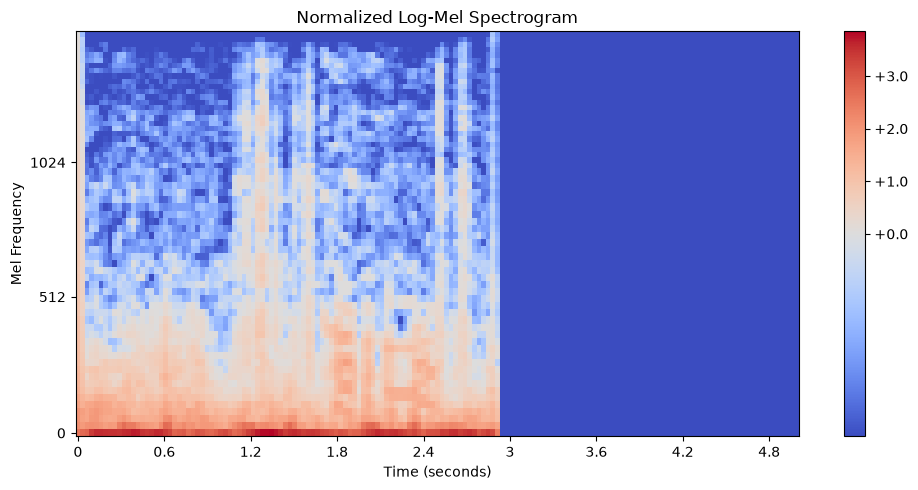

In [50]:
plt.figure(figsize=(10, 5))

librosa.display.specshow(
    example_normalized,
    sr=TARGET_SR,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel",
    fmin=FMIN,
    fmax=FMAX
)

plt.colorbar(format="%+2.1f")
plt.title("Normalized Log-Mel Spectrogram")
plt.xlabel("Time (seconds)")
plt.ylabel("Mel Frequency")

plt.tight_layout()
plt.show()

In [51]:
# ============================================================
# CNN INPUT SHAPE
# ============================================================

example_cnn_input = example_normalized[..., np.newaxis]

print("Before channel dimension:")
print(example_normalized.shape)

print("\nAfter channel dimension:")
print(example_cnn_input.shape)

assert example_cnn_input.shape == (
    N_MELS,
    157,
    1
)

assert np.isfinite(example_cnn_input).all()

print("\nCNN input shape validation passed.")

Before channel dimension:
(64, 157)

After channel dimension:
(64, 157, 1)

CNN input shape validation passed.


In [52]:
# ============================================================
# VERIFY SAMPLE / LABEL / METADATA ALIGNMENT
# ============================================================

sample_row = train_manifest.iloc[example_index]

print("=" * 70)
print("CNN SAMPLE ALIGNMENT CHECK")
print("=" * 70)

print("Sample index :", example_index)
print("Patient ID   :", sample_row["patient_id"])
print("Recording ID :", sample_row["recording_id"])
print("Chest        :", sample_row["chest_location"])
print("Diagnosis    :", sample_row["diagnosis"])
print("Label        :", sample_row["disease_label"])
print("Audio path   :", sample_row["audio_path"])

print(
    "\nStored label:",
    y_train_dl[example_index]
)

assert (
    y_train_dl[example_index]
    == sample_row["disease_label"]
)

print("\nSample and label alignment is correct.")

CNN SAMPLE ALIGNMENT CHECK
Sample index : 0
Patient ID   : 103
Recording ID : 2b2
Chest        : Ar
Diagnosis    : Asthma
Label        : 0
Audio path   : /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/audio/cycles/103/2b2_Ar_001.wav

Stored label: 0

Sample and label alignment is correct.


In [53]:
# ============================================================
# STEP 12 VALIDATION
# ============================================================

assert example_cnn_input.shape == (64, 157, 1)
assert np.isfinite(example_cnn_input).all()

assert len(y_train_dl) == len(train_manifest)
assert len(y_test_dl) == len(test_manifest)

print("=" * 70)
print("STEP 12 VALIDATION PASSED")
print("=" * 70)

print("CNN spatial dimensions : 64 × 157")
print("CNN channels            : 1")
print("Training samples        :", len(train_manifest))
print("Testing samples         :", len(test_manifest))
print("Input representation    : Normalized Log-Mel spectrogram")

STEP 12 VALIDATION PASSED
CNN spatial dimensions : 64 × 157
CNN channels            : 1
Training samples        : 4142
Testing samples         : 2756
Input representation    : Normalized Log-Mel spectrogram


## Notebook 10 — Deep Learning Data Preparation: Log-Mel Spectrograms

This notebook prepares the processed respiratory-cycle audio for the deep learning experiments in Notebook 11 and later notebooks.

The preprocessing pipeline converts each respiratory cycle into a fixed-size Log-Mel spectrogram representation suitable for CNN-based classification.

### Processing pipeline

Processed respiratory cycle audio  
→ 4 kHz mono audio  
→ fixed 5-second representation  
→ zero-padding / truncation  
→ 64-band Mel spectrogram  
→ conversion to decibel scale  
→ train-only normalization  
→ efficient memory-mapped storage  
→ CNN-ready representation

### Final representation

- Sampling rate: 4,000 Hz
- Fixed duration: 5 seconds
- Samples per cycle: 20,000
- FFT size: 512
- Hop length: 128
- Number of Mel bands: 64
- Frequency range: 0–2,000 Hz
- Spectrogram shape: `(64, 157)`
- CNN channel-ready shape: `(64, 157, 1)`

A fixed 5-second duration was selected because approximately 96.62% of the respiratory cycles can be represented without truncation. Shorter cycles are zero-padded, while longer cycles are truncated.

Normalization statistics were calculated **only from the training data** and the same training statistics were applied to the test data. This prevents information from the test set from influencing preprocessing.

The resulting Log-Mel spectrograms are stored using NumPy memory-mapped arrays so that the complete dataset does not need to be loaded into RAM during model training.

### Important experimental considerations

The actual CNN experiment is performed in **Notebook 11 — Lightweight Mel CNN Baseline**.

Notebook 11 will establish the final **patient-disjoint train/validation/test split**, calculate class weights using training labels only, and perform training-time augmentation. Therefore, no validation-based model selection or augmentation is performed in this notebook.

The next notebook will use this prepared representation to train a lightweight Mel-spectrogram CNN baseline using PyTorch.

### Output

The main outputs of this notebook are:

- `X_train_logmel.npy`
- `X_test_logmel.npy`
- `y_train.npy`
- `y_test.npy`
- `train_manifest.csv`
- `test_manifest.csv`
- `deep_learning_manifest.csv`
- `disease_class_mapping.csv`
- `logmel_train_normalization.csv`

These files provide the reproducible Log-Mel representation required by the subsequent deep learning experiments.